# 🎖️ 2026년 부대 맞춤형 AI·SW 소양교육
## 육군 직무보수교육 - **2일차 실습 노트북**

> **Ⅱ. 데이터 수집 및 전처리**
>  
> - 데이터 수집 개념 및 공공데이터 활용 (data.go.kr)
> - pandas를 이용한 CSV / Excel / JSON 데이터 읽기
> - DataFrame 탐색 (head, info, describe)
> - 데이터 선택·필터링 (loc, iloc, Boolean Indexing)
> - 결측값(Missing Value) 처리
> - 중복 제거·타입 변환·정규화
> - 이상치(Outlier) 탐지 및 처리
> - 데이터 그룹화 & 집계 (groupby)

---

### 📌 노트북 사용법
1. 각 셀을 순서대로 실행합니다. (`Shift + Enter` 또는 ▶ 버튼)
2. 💻 **실습 예제** 셀은 직접 실행하며 결과를 확인합니다.
3. 🔥 **실습문제** 셀에 직접 답안 코드를 작성해 보세요.
4. ✅ **정답 코드** 셀은 스스로 풀어본 뒤 확인하세요.

### 💡 핵심 원리: Garbage In, Garbage Out
> **"쓰레기가 들어오면, 쓰레기가 나온다"**  
> 데이터 분석의 **80%** 는 수집·전처리에 소요됩니다.  
> 수집 단계가 **분석 품질을 결정**합니다.

---

# 🛠️ Chapter 0. 환경 구성 및 샘플 데이터 준비

## 0-1. 주요 라이브러리 import
pandas, numpy, matplotlib은 Colab에 기본 설치되어 있습니다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 버전 확인
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"mpl     : {mpl.__version__}")

pandas  : 2.2.2
numpy   : 2.0.2
mpl     : 3.10.0


## 0-2. 한글 폰트 설정 (Colab 그래프 한글 깨짐 방지)

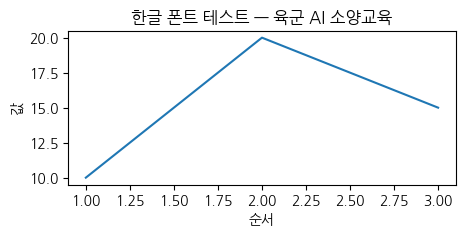

✅ 한글 폰트 설정 완료


In [ ]:
# 나눔고딕 폰트 설치
!apt-get install -qq fonts-nanum > /dev/null 2>&1

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

# 테스트
plt.figure(figsize=(5, 2))
plt.title("한글 폰트 테스트 — 육군 AI 소양교육")
plt.plot([1, 2, 3], [10, 20, 15])
plt.xlabel("순서")
plt.ylabel("값")
plt.show()
print("✅ 한글 폰트 설정 완료")

## 0-3. 실습용 샘플 데이터 생성

외부 파일이 없어도 실습할 수 있도록, **부대원 인사/훈련 데이터** 를 Colab 환경에 직접 만듭니다.

- 의도적으로 **결측값(NaN), 중복 행, 이상치** 를 일부 포함시켰습니다.

In [ ]:
import pandas as pd
import numpy as np

# 재현 가능한 난수
np.random.seed(42)

# 부대원 샘플 데이터
data = {
    "이름":     ["김철수", "이영희", "박민준", "최수진", "정태양",
               "한소희", "윤도현", "강민아", "송지훈", "임서연",
               "오현우", "배유진", "신동욱", "조은비", "문재혁",
               "한소희", "이수민", "박지성", "권나라", "최우식"],
    "부서":     ["행정과", "보급과", "통신과", "행정과", "보급과",
               "통신과", "행정과", "보급과", "통신과", "행정과",
               "보급과", "통신과", "행정과", "보급과", "통신과",
               "통신과", "행정과", "보급과", "행정과", "통신과"],
    "계급":     ["상병", "병장", "이병", "일병", "상병",
               "병장", "이병", "일병", "상병", "병장",
               "이병", "일병", "상병", "병장", "이병",
               "병장", "상병", "일병", "이병", "병장"],
    "입사연도": [2019, 2021, 2020, 2018, 2019,
               2022, 2023, 2021, 2020, 2018,
               2023, 2022, 2019, 2018, 2023,
               2022, 2020, 2021, 2023, 2018],
    "급여":    [420, 380, np.nan, 450, 410,
               390, 250, 350, 430, 470,
               260, 340, 420, 480, 255,
               390, 415, 355, np.nan, 475],
    "훈련점수": [85.2, 92.3, 78.5, 95.1, 88.0,
                np.nan, 72.1, 80.5, 91.2, 87.8,
                75.0, 82.4, 89.6, 94.3, 9999,    # 9999는 이상치
                92.3, 86.7, 79.2, 70.5, 93.1],
    "출석률":   [95.2, 88.7, 72.1, 91.5, 94.8,
                83.2, 78.9, 85.4, 90.1, 96.3,
                75.5, 81.7, 89.4, 97.2, 68.5,
                88.7, 92.3, 84.6, np.nan, 95.7],
    "입대일":   ["2019-03-01", "2021-06-15", "2020-09-10", "2018-04-20", "2019-07-05",
               "2022-02-28", "2023-05-12", "2021-11-03", "2020-08-17", "2018-10-25",
               "2023-01-09", "2022-07-14", "2019-12-22", "2018-05-30", "2023-03-18",
               "2022-02-28", "2020-04-05", "2021-09-19", "2023-06-24", "2018-11-08"]
}

df_original = pd.DataFrame(data)

# CSV로 저장하여 이후 실습에서 파일 읽기 연습에도 사용
df_original.to_csv('/content/soldiers.csv', index=False, encoding='utf-8-sig')
df_original.to_excel('/content/soldiers.xlsx', index=False)

print(f"✅ 샘플 데이터 생성 완료: {df_original.shape[0]}행 × {df_original.shape[1]}열")
print(f"   저장 위치: /content/soldiers.csv, /content/soldiers.xlsx")
df_original.head()

✅ 샘플 데이터 생성 완료: 20행 × 8열
   저장 위치: /content/soldiers.csv, /content/soldiers.xlsx


,이름,부서,계급,입사연도,급여,훈련점수,출석률,입대일
0,김철수,행정과,상병,2019,420.0,85.2,95.2,2019-03-01
1,이영희,보급과,병장,2021,380.0,92.3,88.7,2021-06-15
2,박민준,통신과,이병,2020,NaN,78.5,72.1,2020-09-10
3,최수진,행정과,일병,2018,450.0,95.1,91.5,2018-04-20
4,정태양,보급과,상병,2019,410.0,88.0,94.8,2019-07-05


---
# 📥 Chapter 1. 데이터 수집 (Data Collection)

## 1-1. 데이터 수집이란?
> **분석 목적에 맞는 데이터를 찾고 불러오는 과정**  
> 데이터 분석의 첫 단계이자 가장 중요한 단계입니다.

### 5가지 주요 데이터 수집 방법

| 방법 | 도구 | 특징 |
|---|---|---|
| 🏛 **공공 데이터포털** | data.go.kr | 정부·지자체 무료 제공 |
| 📁 **파일 직접 읽기** | pandas | CSV, Excel, JSON 로컬 파일 |
| 🌐 **웹 스크래핑** | requests + BeautifulSoup | HTML 파싱 |
| 🔌 **API 호출** | requests | REST API, JSON 수신 |
| 🗄 **데이터베이스** | pandas.read_sql() | SQL 쿼리 |

## 1-2. 공공데이터포털 활용 절차
1. **data.go.kr** 회원가입·로그인
2. 원하는 데이터 검색 (예: 날씨, 인구, 교통)
3. 오픈API → 활용신청 → 즉시 승인
4. 마이페이지에서 **API 인증키(서비스키)** 확인

💡 군 관련 활용 가능 공공 데이터 예시:
- 기상청 날씨 예보
- 행정안전부 지역 정보
- 통계청 인구 데이터
- 보건복지부 의료기관
- 교통 CCTV 정보

## 1-3. API 호출 코드 구조 (참고)

아래는 **일반적인 공공 API 호출 패턴**입니다. 실제 실행하려면 본인의 인증키가 필요하므로, 코드 구조만 익혀두세요.

In [ ]:
# ⚠️ 이 셀은 '구조 학습용'입니다. 실제 API 키가 없으면 실행되지 않습니다.

import requests
import pandas as pd

# 공공데이터 API 설정 (예시)
# KEY = '본인_인증키'
# URL = 'http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getVilageFcst'
#
# params = {
#     'serviceKey': KEY,
#     'numOfRows': 100,
#     'pageNo': 1,
#     'dataType': 'JSON',
#     'base_date': '20260428',
#     'base_time': '0600',
#     'nx': 60, 'ny': 127   # 좌표
# }
#
# r = requests.get(URL, params=params)
# data = r.json()
# df = pd.DataFrame(data['response']['body']['items']['item'])
# df.head()

print("👆 실제 실행하려면 주석 해제 후 본인의 API 인증키를 입력하세요.")
print("   data.go.kr 회원가입 → 데이터 검색 → 활용신청 → 인증키 발급")

In [ ]:
# 필요한 라이브러리 설치 (Colab 기본 포함이지만 명시)
import requests
import pandas as pd
from datetime import datetime, timedelta

# 본인의 KOBIS API KEY 입력
API_KEY = "03a1dcfe39941937c1d583fd8583a2d7"

# 어제 날짜 계산 (박스오피스는 하루 단위)
yesterday = datetime.now() - timedelta(days=1)
target_date = yesterday.strftime("%Y%m%d")

# API URL
url = "http://kobis.or.kr/kobisopenapi/webservice/rest/boxoffice/searchDailyBoxOfficeList.json"

# 요청 파라미터
params = {
    "key": API_KEY,
    "targetDt": target_date
}

# API 요청
response = requests.get(url, params=params)
data = response.json()

# 데이터 파싱
movies = data['boxOfficeResult']['dailyBoxOfficeList']

# 데이터프레임 변환
df = pd.DataFrame(movies)

# 필요한 컬럼만 선택
df = df[['rank', 'movieNm', 'openDt', 'audiCnt', 'audiAcc']]

# 컬럼명 변경 (한글)
df.columns = ['순위', '영화명', '개봉일', '당일관객수', '누적관객수']

# 결과 출력
print(f"📅 {target_date} 박스오피스 순위")
df

📅 20260427 박스오피스 순위


,순위,영화명,개봉일,당일관객수,누적관객수
0,1,살목지,2026-04-08,41902,2025662
1,2,짱구,2026-04-22,15630,179528
2,3,프로젝트 헤일메리,2026-03-18,15612,2506504
3,4,왕과 사는 남자,2026-02-04,10114,16716939
4,5,란 12.3,2026-04-22,7279,140927
5,6,내 이름은,2026-04-15,4074,165682
6,7,리 크로닌의 미이라,2026-04-22,2758,30945
7,8,기동전사 건담: 섬광의 하사웨이 키르케의 마녀,2026-04-22,1329,19744
8,9,악마는 프라다를 입는다 2,2026-04-29,1001,1001
9,10,마녀배달부 키키,2007-11-22,949,116644


In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta

# 본인 서비스 키 입력 (Decoding 키 사용)
SERVICE_KEY = "db58745252b606790b96cfa2a8692bb0d31aaf4ab2cadfe036ee5e3c27a1463b"

# 현재 시간 기준 가장 최근 발표시간 계산
now = datetime.now()

# 발표 시간은 매시 40분 이후 데이터 제공 → 1시간 전 기준
if now.minute < 40:
    base_time = (now - timedelta(hours=1)).strftime("%H00")
    base_date = (now - timedelta(hours=1)).strftime("%Y%m%d")
else:
    base_time = now.strftime("%H00")
    base_date = now.strftime("%Y%m%d")

# API URL
url = "http://apis.data.go.kr/1360000/VilageFcstInfoService_2.0/getUltraSrtNcst"

# 파라미터 설정
params = {
    "serviceKey": SERVICE_KEY,
    "numOfRows": "10",
    "pageNo": "1",
    "dataType": "JSON",
    "base_date": base_date,
    "base_time": base_time,
    "nx": "67",  # 대전
    "ny": "100"
}

# 요청
response = requests.get(url, params=params)
data = response.json()

# 데이터 추출
items = data['response']['body']['items']['item']

# 필요한 데이터 정리
weather_dict = {}

for item in items:
    category = item['category']
    value = item['obsrValue']

    weather_dict[category] = value

# 의미 변환
result = {
    "기온(℃)": weather_dict.get("T1H"),
    "습도(%)": weather_dict.get("REH"),
    "풍속(m/s)": weather_dict.get("WSD"),
    "강수량(mm)": weather_dict.get("RN1"),
}

# 출력
print(f"📅 기준시간: {base_date} {base_time}")
print("📍 대전 현재 날씨")
for k, v in result.items():
    print(f"{k}: {v}")

📅 기준시간: 20260428 0300
📍 대전 현재 날씨
기온(℃): 14.4
습도(%): 69
풍속(m/s): 2.5
강수량(mm): 0


---
### 🔥 실습문제 1
아래 질문에 답해보세요. (`answer` 변수에 숫자로 답 저장)

1. 데이터 분석에서 수집·전처리 단계가 차지하는 비율은 몇 %인가?
2. 공공데이터포털의 정식 URL은?  
   (① kosis.kr ② data.go.kr ③ open.go.kr)

In [ ]:
# ✍️ 여기에 답을 작성하세요
answer_1 = 80     # 숫자 (%) 입력
answer_2 = 2     # 1, 2, 3 중 하나

print(f"답 1: {answer_1}%")
print(f"답 2: {answer_2}번")

답 1: 80%
답 2: 2번


**✅ 정답**

In [ ]:
answer_1 = 80         # 80% (PPT 내용)
answer_2 = 2          # ② data.go.kr

print(f"답 1: {answer_1}% → 데이터 분석의 80%는 수집·전처리에 소요")
print(f"답 2: {answer_2}번 → data.go.kr (공공데이터포털)")

---
# 📂 Chapter 2. pandas로 다양한 형식의 데이터 읽기

> **pandas** = 데이터를 **DataFrame(표 형태)** 으로 읽어 분석하기 쉽게 만들어주는 Python 핵심 라이브러리

## 2-1. CSV 파일 읽기 — `pd.read_csv()`

In [ ]:
import pandas as pd

# 기본 읽기
df = pd.read_csv('/content/soldiers.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (20, 8)


,이름,부서,계급,입사연도,급여,훈련점수,출석률,입대일
0,김철수,행정과,상병,2019,420.0,85.2,95.2,2019-03-01
1,이영희,보급과,병장,2021,380.0,92.3,88.7,2021-06-15
2,박민준,통신과,이병,2020,NaN,78.5,72.1,2020-09-10
3,최수진,행정과,일병,2018,450.0,95.1,91.5,2018-04-20
4,정태양,보급과,상병,2019,410.0,88.0,94.8,2019-07-05


In [ ]:
# 자주 쓰는 옵션
df = pd.read_csv(
    '/content/soldiers.csv',
    encoding='utf-8-sig',    # 한글 인코딩 (cp949, euc-kr 등 가능)
    sep=',',                 # 구분자 (탭은 '\t')
    header=0,                # 첫 행을 헤더로
)
df.head(3)

,이름,부서,계급,입사연도,급여,훈련점수,출석률,입대일
0,김철수,행정과,상병,2019,420.0,85.2,95.2,2019-03-01
1,이영희,보급과,병장,2021,380.0,92.3,88.7,2021-06-15
2,박민준,통신과,이병,2020,NaN,78.5,72.1,2020-09-10


## 2-2. Excel 파일 읽기 — `pd.read_excel()`

In [ ]:
# 기본 읽기
df_xl = pd.read_excel('/content/soldiers.xlsx')
df_xl.head(3)

,이름,부서,계급,입사연도,급여,훈련점수,출석률,입대일
0,김철수,행정과,상병,2019,420.0,85.2,95.2,2019-03-01
1,이영희,보급과,병장,2021,380.0,92.3,88.7,2021-06-15
2,박민준,통신과,이병,2020,NaN,78.5,72.1,2020-09-10


In [ ]:
# 주요 옵션 정리
# ─────────────────────────────────────────────────
# sheet_name=0           첫 번째 시트 (기본값)
# sheet_name='3월'       시트 이름으로 선택
# sheet_name=None        모든 시트를 딕셔너리로 반환
# header=1               2번째 행을 헤더로 사용
# skiprows=2             상단 2행 건너뛰기
# usecols='A:D'          A~D 열만 읽기
# engine='openpyxl'      한글 엑셀 파일 깨짐 방지

# 예시: 일부 컬럼만 읽기
df_part = pd.read_excel(
    '/content/soldiers.xlsx',
    usecols='A:E',    # A~D 열만
    engine='openpyxl'
)
df_part.head()

,이름,부서,계급,입사연도,급여
0,김철수,행정과,상병,2019,420.0
1,이영희,보급과,병장,2021,380.0
2,박민준,통신과,이병,2020,NaN
3,최수진,행정과,일병,2018,450.0
4,정태양,보급과,상병,2019,410.0


## 2-3. JSON 파일 읽기 — `pd.read_json()`, `json_normalize()`

In [ ]:
import json

# 샘플 JSON 데이터 생성
sample_json = {
    "items": [
        {"이름": "김철수", "계급": "상병", "점수": 85},
        {"이름": "이영희", "계급": "병장", "점수": 92},
        {"이름": "박민준", "계급": "이병", "점수": 78}
    ]
}

# 파일로 저장
with open('/content/soldiers.json', 'w', encoding='utf-8') as f:
    json.dump(sample_json, f, ensure_ascii=False, indent=2)

# 방법 1: pd.DataFrame()
df_json = pd.DataFrame(sample_json['items'])
print("[ 방법 1: DataFrame() ]")
print(df_json)

# 방법 2: json_normalize (중첩 구조도 평탄화)
from pandas import json_normalize
df_norm = json_normalize(sample_json['items'])
print("\n[ 방법 2: json_normalize ]")
print(df_norm)

[ 방법 1: DataFrame() ]
    이름  계급  점수
0  김철수  상병  85
1  이영희  병장  92
2  박민준  이병  78

[ 방법 2: json_normalize ]
    이름  계급  점수
0  김철수  상병  85
1  이영희  병장  92
2  박민준  이병  78


## 2-4. Google Drive에서 파일 읽기 (참고)

Drive에 파일이 있는 경우 아래와 같이 마운트 후 경로로 불러옵니다.

```python
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/데이터/military_data.csv')
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/milaisw/military_meal_2026_H1.csv')
df.head()

Mounted at /content/drive


,날짜,요일,식사구분,메뉴번호,메뉴명,음식분류,칼로리(kcal),단백질(g),지방(g),탄수화물(g),나트륨(mg),당류(g),식이섬유(g),콜레스테롤(mg),포화지방(g),원산지,보관방법,알레르기유발물질,비고
0,2026-01-01,목,조식,1,팥밥,주식,338,5.0,21.4,31.4,897,13.2,1.2,72,3.7,호주산,상온보관,"우유,계란",신정 특별식
1,2026-01-01,목,조식,2,삼계탕국물,국/찌개,108,5.4,9.5,5.0,567,7.2,3.1,88,1.0,국내산,상온보관,우유,신정 특별식
2,2026-01-01,목,조식,3,삼겹살구이,주찬,253,8.7,17.2,15.9,256,1.1,2.7,17,4.8,국내산,냉장보관,"난류,밀,대두",신정 특별식
3,2026-01-01,목,조식,4,상추무침,부찬,59,6.5,5.6,5.0,697,12.6,3.5,41,5.6,국내산,상온보관,"대두,밀",신정 특별식
4,2026-01-01,목,조식,5,두부부침,부찬,65,31.4,18.8,5.0,617,12.1,5.9,0,7.7,중국산,상온보관,우유,신정 특별식


---
### 🔥 실습문제 2
위에서 저장한 `/content/soldiers.csv` 파일을 다음 조건으로 읽어 오세요.

1. 인코딩: `utf-8-sig`
2. 컬럼 `"이름"`, `"계급"`, `"훈련점수"` **3개 열만** 읽기 (`usecols` 옵션)
3. 상위 5행 출력

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
df_selected = pd.read_csv(
    '/content/soldiers.csv',
    encoding='utf-8-sig',
    usecols=['이름', '계급', '훈련점수']
)

print(f"Shape: {df_selected.shape}")
df_selected.head()

---
# 🔍 Chapter 3. 데이터 탐색 — DataFrame 기본 함수

> 💡 데이터를 불러온 후 **가장 먼저** 해야 할 일:  
> 형태·구조·통계를 파악하여 **전처리 전략을 세우기**

## 3-1. 데이터를 처음 받았을 때 확인하는 6가지

| 함수 | 역할 |
|---|---|
| `df.head()` | 상위 5행 미리보기 |
| `df.tail()` | 하위 5행 미리보기 |
| `df.shape` | (행 수, 열 수) 확인 |
| `df.info()` | 컬럼명·자료형·결측값 요약 |
| `df.describe()` | 수치형 통계 요약 (평균, 표준편차, 사분위수) |
| `df.columns` / `df.dtypes` | 컬럼명 / 자료형 목록 |

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# ① 상위 5행
print("─" * 40)
print("① df.head()")
print("─" * 40)
df.head()

────────────────────────────────────────
① df.head()
────────────────────────────────────────


,이름,부서,계급,입사연도,급여,훈련점수,출석률,입대일
0,김철수,행정과,상병,2019,420.0,85.2,95.2,2019-03-01
1,이영희,보급과,병장,2021,380.0,92.3,88.7,2021-06-15
2,박민준,통신과,이병,2020,NaN,78.5,72.1,2020-09-10
3,최수진,행정과,일병,2018,450.0,95.1,91.5,2018-04-20
4,정태양,보급과,상병,2019,410.0,88.0,94.8,2019-07-05


In [ ]:
# ② 하위 3행
print("② df.tail(3)")
print(df.tail(3))

② df.tail(3)
     이름   부서  계급  입사연도     급여  훈련점수   출석률         입대일
17  박지성  보급과  일병  2021  355.0  79.2  84.6  2021-09-19
18  권나라  행정과  이병  2023    NaN  70.5   NaN  2023-06-24
19  최우식  통신과  병장  2018  475.0  93.1  95.7  2018-11-08


In [ ]:
# ③ 데이터 크기
print(f"③ df.shape = {df.shape}")
print(f"   → {df.shape[0]}행 × {df.shape[1]}열")

③ df.shape = (20, 8)
   → 20행 × 8열


In [ ]:
# ④ df.info() - 구조 전체 파악
print("④ df.info()")
df.info()

④ df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   이름      20 non-null     object 
 1   부서      20 non-null     object 
 2   계급      20 non-null     object 
 3   입사연도    20 non-null     int64  
 4   급여      18 non-null     float64
 5   훈련점수    19 non-null     float64
 6   출석률     19 non-null     float64
 7   입대일     20 non-null     object 
dtypes: float64(3), int64(1), object(4)
memory usage: 1.4+ KB


In [ ]:
# ⑤ df.describe() - 수치형 통계 요약
print("⑤ df.describe()")
df.describe()

⑤ df.describe()


,입사연도,급여,훈련점수,출석률
count,20.000000,18.000000,19.000000,19.000000
mean,2020.500000,385.555556,606.989474,86.831579
std,1.849609,72.576306,2274.391597,8.420283
min,2018.000000,250.000000,70.500000,68.500000
25%,2019.000000,351.250000,79.850000,82.450000
50%,2020.500000,400.000000,87.800000,88.700000
75%,2022.000000,427.500000,92.300000,93.550000
max,2023.000000,480.000000,9999.000000,97.200000


In [ ]:
# ⑥ 컬럼명 & 자료형
print(f"⑥-1 컬럼 목록:\n{df.columns.tolist()}")
print(f"\n⑥-2 자료형:\n{df.dtypes}")

⑥-1 컬럼 목록:
['이름', '부서', '계급', '입사연도', '급여', '훈련점수', '출석률', '입대일']

⑥-2 자료형:
이름       object
부서       object
계급       object
입사연도      int64
급여      float64
훈련점수    float64
출석률     float64
입대일      object
dtype: object


## 3-2. 결측값 개수 확인

In [ ]:
# 컬럼별 결측값 개수
print("[ 컬럼별 결측값 개수 ]")
print(df.isnull().sum())

# 결측 비율(%)
print("\n[ 결측 비율(%) ]")
print((df.isnull().sum() / len(df) * 100).round(2))

[ 컬럼별 결측값 개수 ]
이름      0
부서      0
계급      0
입사연도    0
급여      2
훈련점수    1
출석률     1
입대일     0
dtype: int64

[ 결측 비율(%) ]
이름       0.0
부서       0.0
계급       0.0
입사연도     0.0
급여      10.0
훈련점수     5.0
출석률      5.0
입대일      0.0
dtype: float64


## 3-3. 고유값(Unique Value) 확인

In [ ]:
# 부서별 인원 수
print("[ 부서별 인원 수 ]")
print(df['부서'].value_counts())

# 고유값 목록
print(f"\n[ 계급 종류 ]: {df['계급'].unique()}")
print(f"[ 부서 종류 ]: {df['부서'].unique()}")
print(f"[ 계급 개수 ]: {df['계급'].nunique()}개")

[ 부서별 인원 수 ]
부서
행정과    7
통신과    7
보급과    6
Name: count, dtype: int64

[ 계급 종류 ]: ['상병' '병장' '이병' '일병']
[ 부서 종류 ]: ['행정과' '보급과' '통신과']
[ 계급 개수 ]: 4개


---
### 🔥 실습문제 3
`df` 데이터에 대해 다음을 수행하세요.

1. 전체 행 수, 열 수를 한 줄로 출력 (예: `데이터: 20행 × 8열`)
2. `"입사연도"` 컬럼의 **최솟값과 최댓값** 출력
3. `"출석률"` 컬럼의 **평균값** 을 소수점 둘째 자리까지 출력
4. `"부서"` 컬럼에서 **각 부서별 인원 수** 출력

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 데이터 크기
print(f"데이터: {df.shape[0]}행 × {df.shape[1]}열")

# 2) 입사연도 범위
print(f"입사연도: {df['입사연도'].min()} ~ {df['입사연도'].max()}")

# 3) 출석률 평균
print(f"출석률 평균: {df['출석률'].mean():.2f}%")

# 4) 부서별 인원
print("\n부서별 인원 수:")
print(df['부서'].value_counts())

---
# 🎯 Chapter 4. 데이터 선택 & 필터링

원하는 행·열만 골라내는 방법을 배웁니다.

## 4-1. 컬럼 선택

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# 단일 컬럼 → Series
print("[ 단일 컬럼 (Series) ]")
print(df['급여'].head())
print(f"타입: {type(df['급여'])}")

In [ ]:
# 여러 컬럼 → DataFrame (대괄호 2개 주의!)
print("[ 여러 컬럼 (DataFrame) ]")
print(df[['이름', '계급', '급여']].head())

## 4-2. `loc` (라벨 기반) vs `iloc` (위치 기반)

> **loc = 이름으로 / iloc = 번호로**

In [ ]:
# loc: 라벨(이름) 기반
print("[ df.loc[0, '이름'] ]")
print(df.loc[0, '이름'])

print("\n[ df.loc[0:2, ['이름', '급여']] ]")
print(df.loc[0:2, ['이름', '급여']])

# iloc: 위치(정수 index) 기반
print("\n[ df.iloc[0:3, 0:3] ]")
print(df.iloc[0:3, 0:3])

## 4-3. Boolean Indexing (조건 필터링)

In [ ]:
# 급여 400 이상
print("[ 급여 >= 400 ]")
high_pay = df[df['급여'] >= 400]
print(f"인원: {len(high_pay)}명")
high_pay[['이름', '급여']].head()

In [ ]:
# AND 조건: 급여 ≥ 400 AND 출석률 ≥ 90
# 주의: 각 조건을 괄호로 묶기! & 사용 (and 아님)
high = df[(df['급여'] >= 400) & (df['출석률'] >= 90)]
print(f"고급여+성실 인원: {len(high)}명")
high[['이름', '급여', '출석률']]

In [ ]:
# OR 조건
rank_select = df[(df['계급'] == '병장') | (df['계급'] == '상병')]
print(f"병장+상병: {len(rank_select)}명")

# isin(): 특정 값 포함
dept = df[df['부서'].isin(['행정과', '보급과'])]
print(f"행정과+보급과: {len(dept)}명")

# str.contains(): 문자열 포함 검색
kim = df[df['이름'].str.contains('김')]
print(f"'김'씨 인원: {len(kim)}명")
kim[['이름', '부서']]

---
### 🔥 실습문제 4
`df`에서 다음 조건을 만족하는 데이터를 추출하세요.

1. **"통신과"** 에 소속된 부대원 전체 출력
2. 훈련점수가 **90점 이상** 인 부대원의 `이름`, `계급`, `훈련점수` 출력
3. 계급이 **"상병" 또는 "병장"** 이면서 **출석률이 90 이상** 인 부대원 수 출력
4. 이름에 **"이"** 가 포함된 부대원 출력

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 통신과 부대원
print("[ 1. 통신과 부대원 ]")
print(df[df['부서'] == '통신과'])

# 2) 훈련점수 90 이상
print("\n[ 2. 훈련점수 90 이상 ]")
print(df[df['훈련점수'] >= 90][['이름', '계급', '훈련점수']])

# 3) 상병/병장 AND 출석률 90 이상
result3 = df[
    (df['계급'].isin(['상병', '병장'])) &
    (df['출석률'] >= 90)
]
print(f"\n[ 3. 상병/병장 + 출석률 90 이상 ]: {len(result3)}명")
print(result3[['이름', '계급', '출석률']])

# 4) 이름에 '이' 포함
print("\n[ 4. '이' 포함 ]")
print(df[df['이름'].str.contains('이')][['이름', '부서']])

---
# 🕳️ Chapter 5. 결측값(Missing Value) 처리

> ⚠️ **결측값 = 데이터가 비어 있는 값 (NaN, None, 빈칸)**  
> 분석 오류·왜곡의 원인이 되므로 반드시 처리해야 합니다.

## 5-1. 결측값 처리 전략 선택 가이드

| 결측 비율 | 권장 전략 | 예시 |
|---|---|---|
| **< 5%** | 행 삭제 (`dropna`) | 훈련점수 1% 결측 |
| **5~30%** | 평균/중앙값 채우기 | 체력점수 10% 결측 |
| **> 30%** | 열 삭제 고려 | 혈액형 36% 결측 |
| **범주형** | 최빈값(mode)으로 채우기 | 계급 결측 → '하사' |
| **시계열** | 앞/뒤 값(ffill/bfill) | 일별 기온 3일 결측 |

## 5-2. 결측값 확인

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# 결측값 개수
print("[ 컬럼별 결측값 개수 ]")
print(df.isnull().sum())

# 결측 비율
print("\n[ 결측 비율(%) ]")
print((df.isnull().sum() / len(df) * 100).round(2))

In [ ]:
# 결측값이 있는 행 확인
print("[ 급여가 결측인 행 ]")
print(df[df['급여'].isnull()])

## 5-3. 결측값 삭제 — `dropna()`

In [ ]:
# 원본 보존용 복사
df1 = df.copy()
print(f"삭제 전: {df1.shape}")

# 방법 1: 결측 있는 행 전체 삭제
df_drop_all = df1.dropna()
print(f"모든 결측 행 삭제: {df_drop_all.shape}")

# 방법 2: 특정 컬럼 결측인 행만 삭제
df_drop_pay = df1.dropna(subset=['급여'])
print(f"급여 결측 행만 삭제: {df_drop_pay.shape}")

# 방법 3: 모든 값이 결측인 행만 삭제
# df1.dropna(how='all')

# 방법 4: 임계값 (유효값 n개 미만인 행 삭제)
# df1.dropna(thresh=6)

## 5-4. 결측값 채우기 — `fillna()`

In [ ]:
df2 = df.copy()

# 방법 1: 고정값으로 채우기
df2_zero = df2['급여'].fillna(0)
print(f"[ 급여를 0으로 채우기 ]\n   2번 행 급여: {df2_zero[2]}")

# 방법 2: 평균값으로 채우기 (수치형 권장)
mean_pay = df2['급여'].mean()
df2['급여'] = df2['급여'].fillna(mean_pay)
print(f"\n[ 평균값 ({mean_pay:.1f})으로 채우기 완료 ]")
print(df2[['이름', '급여']].iloc[:5])

In [ ]:
df3 = df.copy()

# 방법 3: 중앙값으로 채우기 (이상치에 덜 민감)
df3['출석률'] = df3['출석률'].fillna(df3['출석률'].median())
print(f"출석률 중앙값으로 채우기 완료, 결측값: {df3['출석률'].isnull().sum()}개")

# 방법 4: 최빈값으로 채우기 (범주형)
# most = df3['계급'].mode()[0]
# df3['계급'] = df3['계급'].fillna(most)

# 방법 5: 앞/뒤 값으로 채우기 (시계열)
# df3.fillna(method='ffill')    # forward fill
# df3.fillna(method='bfill')    # backward fill

---
### 🔥 실습문제 5
다음 순서대로 결측값을 처리하세요.

1. `df_raw = pd.read_csv(...)`로 원본 다시 읽기
2. 결측값 **비율(%)** 확인하여 출력
3. `"급여"` 컬럼의 결측값을 **평균값**으로 채우기
4. `"훈련점수"` 컬럼의 결측값을 **중앙값**으로 채우기
5. `"출석률"` 컬럼이 결측인 **행을 삭제**
6. 처리 후 `isnull().sum()` 으로 결측값이 모두 제거되었는지 확인

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 원본 다시 읽기
df_raw = pd.read_csv('/content/soldiers.csv')
print(f"원본: {df_raw.shape}")

# 2) 결측값 비율
print("\n[ 처리 전 결측값 비율(%) ]")
print((df_raw.isnull().sum() / len(df_raw) * 100).round(2))

# 3) 급여 → 평균
df_raw['급여'] = df_raw['급여'].fillna(df_raw['급여'].mean())

# 4) 훈련점수 → 중앙값
df_raw['훈련점수'] = df_raw['훈련점수'].fillna(df_raw['훈련점수'].median())

# 5) 출석률 결측 행 삭제
df_raw = df_raw.dropna(subset=['출석률'])

# 6) 최종 확인
print(f"\n처리 후: {df_raw.shape}")
print("\n[ 처리 후 결측값 개수 ]")
print(df_raw.isnull().sum())

---
# 🔧 Chapter 6. 중복 제거 · 타입 변환 · 정규화

## 6-1. 중복 행 처리

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# 중복 여부 확인
print(f"중복된 행 수: {df.duplicated().sum()}개")

# 중복 행 보기 (동명이인 '한소희' 케이스)
print("\n[ 이름 기준 중복 확인 ]")
dup_names = df[df['이름'].duplicated(keep=False)].sort_values('이름')
print(dup_names[['이름', '부서', '계급', '입대일']])

중복된 행 수: 0개

[ 이름 기준 중복 확인 ]
     이름   부서  계급         입대일
5   한소희  통신과  병장  2022-02-28
15  한소희  통신과  병장  2022-02-28


In [ ]:
# 중복 제거 (기본: 첫 번째 행 유지)
df_nodup = df.drop_duplicates()
print(f"전체 컬럼 기준 제거: {df.shape} → {df_nodup.shape}")

# 특정 컬럼 기준 중복 제거
df_nodup_name = df.drop_duplicates(subset=['이름'])
print(f"이름 기준 제거: {df.shape} → {df_nodup_name.shape}")

# keep 옵션
# keep='first' (기본) - 처음 것만 유지
# keep='last'         - 마지막 것만 유지
# keep=False          - 중복된 것 모두 삭제

전체 컬럼 기준 제거: (20, 8) → (20, 8)
이름 기준 제거: (20, 8) → (19, 8)


## 6-2. 데이터 타입 변환 — `astype()`

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# 변환 전 타입 확인
print("[ 변환 전 dtypes ]")
print(df.dtypes)

[ 변환 전 dtypes ]
이름       object
부서       object
계급       object
입사연도      int64
급여      float64
훈련점수    float64
출석률     float64
입대일      object
dtype: object


In [ ]:
# 문자열 → 날짜 (가장 중요한 변환)
df['입대일'] = pd.to_datetime(df['입대일'])

# 연/월/일 추출 가능
df['입대연도'] = df['입대일'].dt.year
df['입대월']   = df['입대일'].dt.month
df['요일']     = df['입대일'].dt.day_name()

print("[ 날짜 변환 후 ]")
print(df[['이름', '입대일', '입대연도', '입대월', '요일']].head())
print(f"\n입대일 타입: {df['입대일'].dtype}")

[ 날짜 변환 후 ]
    이름        입대일  입대연도  입대월        요일
0  김철수 2019-03-01  2019    3    Friday
1  이영희 2021-06-15  2021    6   Tuesday
2  박민준 2020-09-10  2020    9  Thursday
3  최수진 2018-04-20  2018    4    Friday
4  정태양 2019-07-05  2019    7    Friday

입대일 타입: datetime64[ns]


In [ ]:
# 범주형으로 변환 (메모리 절약)
df['계급'] = df['계급'].astype('category')
print(f"계급 타입: {df['계급'].dtype}")
print(f"카테고리: {df['계급'].cat.categories.tolist()}")

계급 타입: category
카테고리: ['병장', '상병', '이병', '일병']


## 6-3. 정규화 (Normalization) & 표준화 (Standardization)

| 방법 | 수식 | 결과 범위 | 언제? |
|---|---|---|---|
| **Min-Max 정규화** | (x - min) / (max - min) | 0 ~ 1 | 범위 통일 |
| **표준화 (Z-score)** | (x - 평균) / 표준편차 | 평균=0, 표준편차=1 | 이상치 영향 최소화 |

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 원본 데이터 준비 (이상치 9999 제거 후)
df_clean = df[df['훈련점수'] < 1000].copy().reset_index(drop=True)

# ① Min-Max 정규화 (0~1)
mm = MinMaxScaler()
df_clean['훈련점수_정규화'] = mm.fit_transform(df_clean[['훈련점수']])

# ② 표준화 (Z-score)
std = StandardScaler()
df_clean['훈련점수_표준화'] = std.fit_transform(df_clean[['훈련점수']])

print(df_clean[['이름', '훈련점수', '훈련점수_정규화', '훈련점수_표준화']].head(10).round(3))

print(f"\n정규화 범위 : {df_clean['훈련점수_정규화'].min():.3f} ~ {df_clean['훈련점수_정규화'].max():.3f}")
print(f"표준화 평균 : {df_clean['훈련점수_표준화'].mean():.3f}")
print(f"표준화 표편 : {df_clean['훈련점수_표준화'].std():.3f}")

    이름  훈련점수  훈련점수_정규화  훈련점수_표준화
0  김철수  85.2     0.598    -0.001
1  이영희  92.3     0.886     0.942
2  박민준  78.5     0.325    -0.892
3  최수진  95.1     1.000     1.314
4  정태양  88.0     0.711     0.371
5  윤도현  72.1     0.065    -1.743
6  강민아  80.5     0.407    -0.626
7  송지훈  91.2     0.841     0.796
8  임서연  87.8     0.703     0.344
9  오현우  75.0     0.183    -1.357

정규화 범위 : 0.000 ~ 1.000
표준화 평균 : 0.000
표준화 표편 : 1.029


## 6-4. 범주형 데이터 인코딩

In [ ]:
df_enc = pd.read_csv('/content/soldiers.csv')

# 방법 1: map() - 순서가 있는 범주형 (ordinal)
rank_map = {'이병': 1, '일병': 2, '상병': 3, '병장': 4}
df_enc['계급코드'] = df_enc['계급'].map(rank_map)

print("[ map()을 이용한 레이블 인코딩 ]")
print(df_enc[['이름', '계급', '계급코드']].head())

[ map()을 이용한 레이블 인코딩 ]
    이름  계급  계급코드
0  김철수  상병     3
1  이영희  병장     4
2  박민준  이병     1
3  최수진  일병     2
4  정태양  상병     3


In [ ]:
# 방법 2: pd.get_dummies() - 원-핫 인코딩 (순서 없는 범주형)
df_dummies = pd.get_dummies(df_enc[['이름', '부서']], columns=['부서'])
print("[ 원-핫 인코딩 ]")
print(df_dummies.head())

---
### 🔥 실습문제 6
`df = pd.read_csv('/content/soldiers.csv')` 를 원본으로 다음을 수행하세요.

1. **이름 기준** 중복 행을 제거 (처음 발견된 행만 유지)
2. `"입대일"` 컬럼을 **datetime** 타입으로 변환
3. `"입대요일"` 이라는 새 컬럼을 만들고 **요일(한글, 예: '월요일')** 채우기
4. `"급여"` 컬럼을 **Min-Max 정규화**하여 `"급여_정규화"` 컬럼 추가
5. 결과 5행 출력

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/soldiers.csv')

# 1) 이름 기준 중복 제거
df = df.drop_duplicates(subset=['이름'], keep='first').reset_index(drop=True)
print(f"중복 제거 후: {df.shape}")

# 2) 입대일 → datetime
df['입대일'] = pd.to_datetime(df['입대일'])

# 3) 요일 컬럼 (한글)
weekday_kr = {0: '월요일', 1: '화요일', 2: '수요일',
              3: '목요일', 4: '금요일', 5: '토요일', 6: '일요일'}
df['입대요일'] = df['입대일'].dt.weekday.map(weekday_kr)

# 4) 급여 정규화 (결측값은 먼저 평균으로 채운 후 정규화)
df['급여'] = df['급여'].fillna(df['급여'].mean())
mm = MinMaxScaler()
df['급여_정규화'] = mm.fit_transform(df[['급여']])

# 5) 결과 확인
df[['이름', '입대일', '입대요일', '급여', '급여_정규화']].head().round(3)

중복 제거 후: (19, 8)


,이름,입대일,입대요일,급여,급여_정규화
0,김철수,2019-03-01,금요일,420.000,0.739
1,이영희,2021-06-15,화요일,380.000,0.565
2,박민준,2020-09-10,목요일,385.294,0.588
3,최수진,2018-04-20,금요일,450.000,0.870
4,정태양,2019-07-05,금요일,410.000,0.696


---
# 📊 Chapter 7. 이상치(Outlier) 탐지 및 처리

> ⚠️ **이상치** = 다른 데이터와 크게 벗어난 값  
> 예: 급여가 0원, 나이가 200세, 출석률이 150%, 훈련점수가 9999점 등

## 7-1. `describe()` 로 분포 확인

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# 수치형 컬럼 통계
print(df[['급여', '훈련점수', '출석률']].describe().round(2))

# 🔍 훈련점수 max가 9999로 나타남 → 이상치!
print(f"\n훈련점수 min: {df['훈련점수'].min()}")
print(f"훈련점수 max: {df['훈련점수'].max()}   ← 이상치 의심")

           급여     훈련점수    출석률
count   18.00    19.00  19.00
mean   385.56   606.99  86.83
std     72.58  2274.39   8.42
min    250.00    70.50  68.50
25%    351.25    79.85  82.45
50%    400.00    87.80  88.70
75%    427.50    92.30  93.55
max    480.00  9999.00  97.20

훈련점수 min: 70.5
훈련점수 max: 9999.0   ← 이상치 의심


## 7-2. IQR 방법 (실무에서 가장 많이 씀)

```
IQR = Q3 - Q1   (사분위 범위)
이상치 범위: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
이 범위를 벗어나면 이상치로 판정
```

In [ ]:
# 훈련점수에서 이상치 탐지
col = '훈련점수'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1       : {Q1:.2f}")
print(f"Q3       : {Q3:.2f}")
print(f"IQR      : {IQR:.2f}")
print(f"하한값   : {lower:.2f}")
print(f"상한값   : {upper:.2f}")

# 이상치 추출
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f"\n⚠️ 이상치 {len(outliers)}개 발견")
print(outliers[['이름', col]])

Q1       : 79.85
Q3       : 92.30
IQR      : 12.45
하한값   : 61.17
상한값   : 110.97

⚠️ 이상치 1개 발견
     이름    훈련점수
14  문재혁  9999.0


## 7-3. 이상치 처리 방법

In [ ]:
# 방법 1: 이상치 제거
df_clean = df[(df[col] >= lower) & (df[col] <= upper)].copy()
print(f"제거 전: {df.shape[0]}행 → 제거 후: {df_clean.shape[0]}행")

# 방법 2: 이상치를 NaN으로 치환 후 평균으로 채우기
df_fix = df.copy()
df_fix.loc[(df_fix[col] < lower) | (df_fix[col] > upper), col] = np.nan
df_fix[col] = df_fix[col].fillna(df_fix[col].mean())

print(f"\n방법 2 결과 (이상치를 평균으로 대체):")
print(df_fix[['이름', col]].iloc[[14]])   # 이상치였던 행

# 방법 3: Capping (경계값으로 변경)
df_cap = df.copy()
df_cap[col] = df_cap[col].clip(lower=lower, upper=upper)
print(f"\n방법 3 결과 (경계값으로 Capping):")
print(df_cap[['이름', col]].iloc[[14]])

제거 전: 20행 → 제거 후: 18행

방법 2 결과 (이상치를 평균으로 대체):
     이름       훈련점수
14  문재혁  85.211111

방법 3 결과 (경계값으로 Capping):
     이름     훈련점수
14  문재혁  110.975


## 7-4. 박스플롯(Boxplot) 시각화

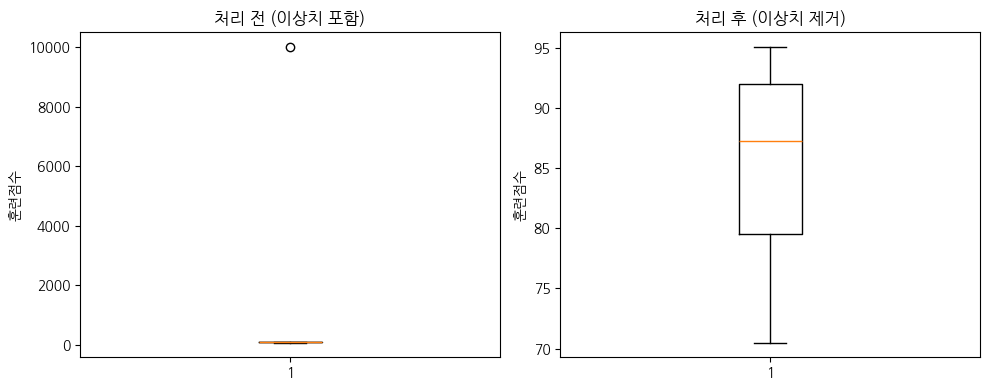

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 이상치 포함 (원본)
axes[0].boxplot(df['훈련점수'].dropna())
axes[0].set_title("처리 전 (이상치 포함)", fontsize=12)
axes[0].set_ylabel("훈련점수")

# 이상치 제거 후
axes[1].boxplot(df_clean['훈련점수'].dropna())
axes[1].set_title("처리 후 (이상치 제거)", fontsize=12)
axes[1].set_ylabel("훈련점수")

plt.tight_layout()
plt.show()

---
### 🔥 실습문제 7
`"급여"` 컬럼에서 **IQR 방법**으로 이상치를 탐지하고 처리하세요.

1. 결측값을 평균값으로 먼저 채우기
2. Q1, Q3, IQR 계산
3. 이상치의 상·하한선 출력
4. 이상치 **개수** 확인
5. 이상치를 **제거한** 새 DataFrame 생성

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
df = pd.read_csv('/content/soldiers.csv')

# 1) 결측값 평균으로 채우기
df['급여'] = df['급여'].fillna(df['급여'].mean())

# 2) IQR 계산
col = '급여'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 3) 범위 출력
print(f"Q1 = {Q1:.1f}, Q3 = {Q3:.1f}, IQR = {IQR:.1f}")
print(f"정상 범위: [{lower:.1f}, {upper:.1f}]")

# 4) 이상치 개수
out_mask = (df[col] < lower) | (df[col] > upper)
print(f"이상치 개수: {out_mask.sum()}개")
if out_mask.sum() > 0:
    print(df[out_mask][['이름', '급여']])

# 5) 이상치 제거
df_clean = df[~out_mask].reset_index(drop=True)
print(f"\n제거 후: {df.shape[0]} → {df_clean.shape[0]}행")

---
# 📈 Chapter 8. 데이터 그룹화 & 집계 — `groupby`

> 실무에서 **가장 자주 쓰는** 분석: 부서별 평균, 월별 합계, 계급별 통계 등

## 8-1. GroupBy 동작 원리: Split → Apply → Combine

```
   ✂️ Split          ⚙️ Apply        🔗 Combine
   ─────────         ────────       ──────────
   그룹 기준으로  →  각 그룹에    →  결과를 합쳐
   데이터 분리       집계 함수 적용    새 DataFrame 생성
```

In [ ]:
# 실습용 깨끗한 데이터 준비
df = pd.read_csv('/content/soldiers.csv')
df['급여'] = df['급여'].fillna(df['급여'].mean())
df['훈련점수'] = df['훈련점수'].replace(9999, np.nan).fillna(df['훈련점수'][df['훈련점수']<1000].mean())
df['출석률'] = df['출석률'].fillna(df['출석률'].median())
df = df.drop_duplicates(subset=['이름'])
df.head(3)

## 8-2. 단일 컬럼 집계

In [ ]:
# 부서별 평균 급여
print("[ 부서별 평균 급여 ]")
print(df.groupby('부서')['급여'].mean().round(1))

# 부서별 인원 수
print("\n[ 부서별 인원 수 ]")
print(df.groupby('부서').size())

# 계급별 평균 훈련점수
print("\n[ 계급별 평균 훈련점수 ]")
print(df.groupby('계급')['훈련점수'].mean().round(2))

## 8-3. 여러 집계 함수 동시 적용 — `agg()`

In [ ]:
# 방법 1: 리스트로 여러 함수
result1 = df.groupby('부서')['급여'].agg(['mean', 'max', 'min', 'count'])
print("[ 부서별 급여 통계 ]")
print(result1.round(1))

In [ ]:
# 방법 2: 컬럼별로 다른 함수 지정
result2 = df.groupby('부서').agg({
    '급여': 'mean',
    '훈련점수': ['mean', 'max'],
    '출석률': 'mean'
}).round(2)

print("[ 부서별 다중 집계 ]")
print(result2)

In [ ]:
# 방법 3: 가독성 좋게 컬럼명 직접 지정
result3 = df.groupby('부서').agg(
    평균급여    = ('급여', 'mean'),
    최대점수    = ('훈련점수', 'max'),
    평균출석률  = ('출석률', 'mean'),
    인원수      = ('이름', 'count')
).round(1).reset_index()

print("[ 이름 지정 집계 (가독성 good) ]")
print(result3)

## 8-4. 다중 그룹 기준

In [ ]:
# 부서 + 계급별 평균 급여
multi = df.groupby(['부서', '계급'])['급여'].mean().round(1)
print("[ 부서 × 계급별 평균 급여 ]")
print(multi)

## 8-5. 피벗 테이블 (Pivot Table) — 엑셀 스타일

In [ ]:
pivot = df.pivot_table(
    index='부서',       # 행
    columns='계급',      # 열
    values='훈련점수',   # 집계 대상
    aggfunc='mean'       # 집계 함수
).round(2)

print("[ 피벗 테이블: 부서 × 계급별 평균 훈련점수 ]")
print(pivot)

## 8-6. 그룹별 집계 결과 시각화

In [ ]:
# 부서별 평균 급여 막대그래프
dept_pay = df.groupby('부서')['급여'].mean().round(1)

plt.figure(figsize=(8, 4))
bars = plt.bar(dept_pay.index, dept_pay.values,
               color=['#2E86AB', '#5BA3C7', '#A7CFE0'], edgecolor='black')

for bar, v in zip(bars, dept_pay.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{v:.1f}', ha='center', fontweight='bold')

plt.title("부서별 평균 급여", fontsize=14, fontweight='bold')
plt.ylabel("평균 급여 (만원)")
plt.ylim(0, max(dept_pay.values) * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
### 🔥 실습문제 8
`df` 데이터에 대해 다음을 수행하세요.

1. **계급별** 평균 급여, 평균 훈련점수, 인원수를 한 번에 출력
2. **부서별** 훈련점수의 **최대값**과 **최소값** 을 계산하여 표로 출력
3. **입사연도별** 평균 출석률 계산 (연도 오름차순 정렬)
4. **피벗 테이블**: 부서(행) × 계급(열)의 **평균 출석률** 생성

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 계급별 종합 집계
print("[ 1. 계급별 종합 통계 ]")
result1 = df.groupby('계급').agg(
    평균급여   = ('급여', 'mean'),
    평균점수   = ('훈련점수', 'mean'),
    인원수     = ('이름', 'count')
).round(2)
print(result1)

# 2) 부서별 훈련점수 max/min
print("\n[ 2. 부서별 훈련점수 범위 ]")
result2 = df.groupby('부서')['훈련점수'].agg(['max', 'min']).round(2)
print(result2)

# 3) 입사연도별 평균 출석률
print("\n[ 3. 입사연도별 평균 출석률 ]")
result3 = df.groupby('입사연도')['출석률'].mean().round(2).sort_index()
print(result3)

# 4) 피벗 테이블
print("\n[ 4. 부서 × 계급 피벗 - 평균 출석률 ]")
pivot = df.pivot_table(
    index='부서', columns='계급',
    values='출석률', aggfunc='mean'
).round(2)
print(pivot)

---
# 🏆 종합 실습 프로젝트 — 데이터 전처리 파이프라인

> 🎯 **목표**: 원본 데이터를 불러와 **결측값 → 중복 → 타입 변환 → 이상치 → 정규화 → 집계** 까지  
> 완결된 **전처리 파이프라인**을 구축합니다.

## 요구사항 체크리스트

- [ ] ① 원본 CSV 불러오기 + shape 확인
- [ ] ② 결측값 확인 및 처리 (급여·훈련점수·출석률)
- [ ] ③ 중복 행 제거 (이름 기준)
- [ ] ④ 타입 변환 (입대일 → datetime)
- [ ] ⑤ 이상치 제거 (훈련점수 IQR 방법)
- [ ] ⑥ 정규화 (급여 Min-Max)
- [ ] ⑦ 그룹 집계 (부서별 평균)
- [ ] ⑧ 시각화 (막대그래프 + 박스플롯)
- [ ] ⑨ 정제된 데이터 저장

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("=" * 50)
print("🚀 데이터 전처리 파이프라인 시작")
print("=" * 50)

# ────────────────────────────────
# ① 데이터 불러오기
# ────────────────────────────────
df = pd.read_csv('/content/soldiers.csv')
print(f"\n① 원본: {df.shape[0]}행 × {df.shape[1]}열")

# ────────────────────────────────
# ② 결측값 처리
# ────────────────────────────────
print(f"\n② 결측값 처리 전:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['급여']     = df['급여'].fillna(df['급여'].mean())
df['훈련점수'] = df['훈련점수'].fillna(df['훈련점수'].median())
df['출석률']   = df['출석률'].fillna(df['출석률'].median())

print(f"\n   ✅ 결측값 처리 후: {df.isnull().sum().sum()}개")

# ────────────────────────────────
# ③ 중복 제거
# ────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=['이름'], keep='first').reset_index(drop=True)
print(f"\n③ 중복 제거: {before} → {len(df)}행 ({before-len(df)}개 제거)")

# ────────────────────────────────
# ④ 타입 변환
# ────────────────────────────────
df['입대일'] = pd.to_datetime(df['입대일'])
df['입대연도'] = df['입대일'].dt.year
print(f"\n④ 타입 변환 완료 (입대일 → datetime)")

# ────────────────────────────────
# ⑤ 이상치 제거 (IQR)
# ────────────────────────────────
col = '훈련점수'
Q1, Q3 = df[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

out_mask = (df[col] < lower) | (df[col] > upper)
print(f"\n⑤ 이상치 탐지: {out_mask.sum()}개")
df = df[~out_mask].reset_index(drop=True)
print(f"   제거 후: {len(df)}행")

# ────────────────────────────────
# ⑥ 정규화
# ────────────────────────────────
mm = MinMaxScaler()
df['급여_정규화'] = mm.fit_transform(df[['급여']]).round(3)
print(f"\n⑥ 급여 정규화 완료 [0, 1] 범위로 변환")

# ────────────────────────────────
# ⑦ 집계
# ────────────────────────────────
print(f"\n⑦ 부서별 요약 통계:")
summary = df.groupby('부서').agg(
    인원수    = ('이름', 'count'),
    평균급여  = ('급여', 'mean'),
    평균점수  = ('훈련점수', 'mean'),
    평균출석  = ('출석률', 'mean')
).round(2)
print(summary)

# ────────────────────────────────
# ⑨ 정제 데이터 저장
# ────────────────────────────────
df.to_csv('/content/soldiers_clean.csv', index=False, encoding='utf-8-sig')
print(f"\n⑨ 저장 완료: /content/soldiers_clean.csv")
print(f"   최종: {df.shape[0]}행 × {df.shape[1]}열")
print("=" * 50)

In [ ]:
# ⑧ 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 부서별 평균 급여 막대그래프
dept_pay = df.groupby('부서')['급여'].mean().round(1)
bars = axes[0].bar(dept_pay.index, dept_pay.values,
                   color=['#2E86AB', '#5BA3C7', '#A7CFE0'], edgecolor='black')
for bar, v in zip(bars, dept_pay.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{v:.1f}', ha='center', fontweight='bold')
axes[0].set_title("부서별 평균 급여", fontsize=13, fontweight='bold')
axes[0].set_ylabel("급여 (만원)")
axes[0].grid(axis='y', alpha=0.3)

# 오른쪽: 부서별 훈련점수 박스플롯
dept_list = df['부서'].unique()
data_list = [df[df['부서']==d]['훈련점수'].values for d in dept_list]
axes[1].boxplot(data_list, labels=dept_list)
axes[1].set_title("부서별 훈련점수 분포", fontsize=13, fontweight='bold')
axes[1].set_ylabel("훈련점수")
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ 전처리 파이프라인 완료! 다음 단계는 3일차 EDA·시각화입니다.")

---
### 🔥 최종 도전 과제
위 파이프라인을 확장하여 다음을 추가해 보세요.

1. **`"복무기간(일수)"`** 컬럼 추가 → 오늘 날짜 - 입대일
2. **계급 코드** 컬럼 추가 (이병=1, 일병=2, 상병=3, 병장=4)
3. **원-핫 인코딩** 적용 → `pd.get_dummies(columns=['부서'])`
4. **종합 점수** 컬럼 추가 → (훈련점수 × 0.6 + 출석률 × 0.4)
5. **종합 점수 상위 5명** 출력

💡 어려우면 ChatGPT/Claude에 Vibe Coding으로 요청하세요!

In [ ]:
# ✍️ 여기에 도전 과제 코드를 작성하세요



**✅ 도전 과제 정답 예시**

In [ ]:
from datetime import datetime

# 원본 정제된 데이터 다시 불러오기
df = pd.read_csv('/content/soldiers_clean.csv')
df['입대일'] = pd.to_datetime(df['입대일'])

# 1) 복무기간(일수)
today = pd.Timestamp.today().normalize()
df['복무기간일'] = (today - df['입대일']).dt.days

# 2) 계급 코드
rank_map = {'이병': 1, '일병': 2, '상병': 3, '병장': 4}
df['계급코드'] = df['계급'].map(rank_map)

# 3) 원-핫 인코딩 (부서)
df_encoded = pd.get_dummies(df, columns=['부서'], prefix='부서')

# 4) 종합 점수
df['종합점수'] = (df['훈련점수'] * 0.6 + df['출석률'] * 0.4).round(2)

# 5) 상위 5명
top5 = df.sort_values('종합점수', ascending=False).head(5)
print("🏆 종합점수 TOP 5")
print(top5[['이름', '계급', '부서', '훈련점수', '출석률', '종합점수']].to_string(index=False))

print("\n[ 원-핫 인코딩 결과 (앞 5행) ]")
print(df_encoded.head().to_string())

---
# 🎓 2일차 학습 정리

## ✅ 오늘 배운 내용

| 챕터 | 핵심 내용 | 주요 함수 |
|---|---|---|
| **1. 데이터 수집** | 공공데이터·API·파일 | `requests.get()` |
| **2. 파일 읽기** | CSV·Excel·JSON | `pd.read_csv/excel/json()` |
| **3. 데이터 탐색** | 구조·통계 파악 | `head/info/describe/shape` |
| **4. 선택·필터링** | 라벨/위치/조건 | `loc/iloc`, Boolean Indexing |
| **5. 결측값 처리** | 삭제·채우기 | `isnull/dropna/fillna` |
| **6. 타입·정규화** | 변환·스케일링 | `astype/MinMaxScaler` |
| **7. 이상치 처리** | IQR·제거·대체 | `quantile/clip` |
| **8. 그룹화·집계** | split-apply-combine | `groupby/agg/pivot_table` |

## 🔄 전처리 표준 파이프라인
```
수집 → 탐색 → 결측값 처리 → 중복 제거 → 타입 변환 →
이상치 제거 → 정규화 → 분석 준비 완료 🚀
```

## 📅 다음 일정
- **3일차**: 데이터 분석 및 가공 (그룹화 심화·피벗·상관분석·시각화)
- **4일차**: 미니 프로젝트 — 부대 실무 데이터 EDA

---
**스마트 강군 육성, 국방 AX(AI 전환)에 만전을 기하겠습니다** 🎖️

*교육기관: (사)한국오픈소스협회 | 문의: 02-6012-7414 / kmil@osskorea.org*